# 02 时域统计特征

**本节目标**

1. 对五种状态信号计算 `time_domain_features` 的全部 10 项时域统计指标；
2. 用表格和归一化柱状图对比各状态下的指标取值；
3. 讨论哪些指标对局部故障敏感、各有什么物理含义。

**背景**（详见 [docs/03 时域统计指标](../docs/03_time_domain.md)）

局部故障的周期性冲击会使信号出现"尖峰"，改变其统计分布形态。
最常用的两个冲击敏感指标：

- **峭度（kurtosis）**：$K = \dfrac{E[(x-\mu)^4]}{\sigma^4}$，高斯信号约为 3，冲击越多越大；
- **峰值因子（crest factor）**：$CF = \dfrac{\max|x|}{x_{rms}}$，峰值相对整体能量的突出程度。

此外还有裕度因子、脉冲因子、波形因子等无量纲指标——无量纲量对转速和载荷变化不敏感，
更适合做状态监测。

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bearing_fault import BearingSimulator, FAULT_TYPES, time_domain_features
from bearing_fault.plotting import FAULT_LABELS, plot_feature_bars

FS, RPM, DURATION, SEED = 12000, 1797, 3.0, 42

## 计算五种信号的特征

用同一个随机种子生成五种状态的信号（便于对比），分别计算时域特征。

In [2]:
features = {}
for fault in FAULT_TYPES:
    x = BearingSimulator(fs=FS, duration=DURATION, rpm=RPM, seed=SEED).signal(fault)
    features[FAULT_LABELS[fault]] = time_domain_features(x)

df = pd.DataFrame(features).T
df.round(3)

,rms,peak,peak_to_peak,std,kurtosis,skewness,crest_factor,impulse_factor,shape_factor,clearance_factor
健康,0.100,0.439,0.854,0.100,2.994,0.009,4.372,5.490,1.256,6.498
内圈故障,0.432,2.199,4.348,0.432,3.543,0.041,5.087,6.492,1.276,7.734
外圈故障,0.324,1.600,3.153,0.324,3.465,0.061,4.939,6.309,1.277,7.528
滚动体故障,0.286,1.854,3.496,0.286,4.521,0.090,6.491,8.428,1.298,10.094
保持架故障,0.109,0.989,1.874,0.109,9.023,0.186,9.086,12.139,1.336,14.593


指标含义速查：`rms` 有效值、`peak` 峰值、`peak_to_peak` 峰峰值、`std` 标准差、
`kurtosis` 峭度、`skewness` 偏度、`crest_factor` 峰值因子、`impulse_factor` 脉冲因子、
`shape_factor` 波形因子、`clearance_factor` 裕度因子。

## 归一化柱状图

各指标量纲差异很大，`plot_feature_bars` 以健康样本为基准做归一化，
便于一眼看出哪些指标在故障状态下显著放大。

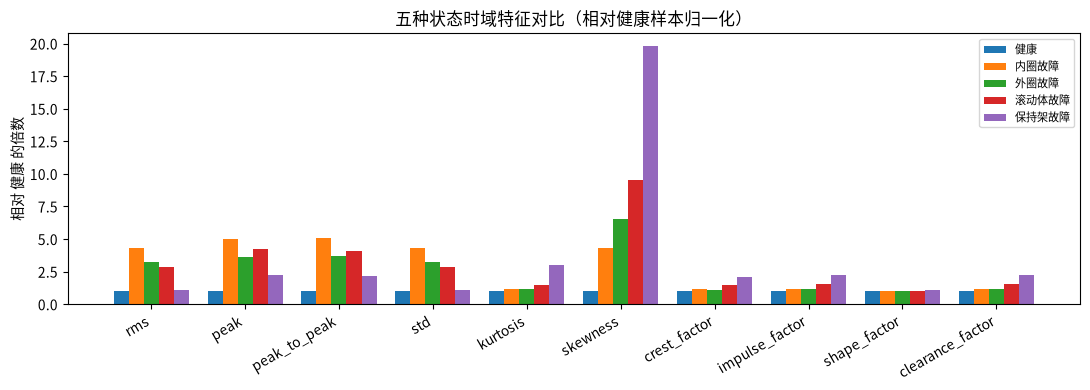

In [3]:
fig, ax = plot_feature_bars(features, title="五种状态时域特征对比（相对健康样本归一化）")
plt.show()

## 哪些指标对故障敏感？

把四类故障的指标取平均，再与健康样本相比，按放大倍数排序：

In [4]:
healthy = df.loc["健康"]
faulty_mean = df.drop(index="健康").mean()
ratio = (faulty_mean / healthy).sort_values(ascending=False)
print("故障/健康 指标放大倍数（降序）：")
print(ratio.round(2).to_string())

故障/健康 指标放大倍数（降序）：
skewness            10.05
peak                 3.78
peak_to_peak         3.77
rms                  2.87
std                  2.87
kurtosis             1.72
clearance_factor     1.54
impulse_factor       1.52
crest_factor         1.46
shape_factor         1.03


**讨论**

- 峭度、峰值因子、脉冲因子、裕度因子这类**无量纲**指标对冲击最敏感——
  故障信号的尖峰让高阶矩和峰值迅速增大，而 RMS 几乎不变；
- RMS、std 等能量类指标也会升高，但受载荷和转速影响大，单独使用不可靠；
- 偏度（skewness）对故障不敏感：对称的冲击响应不会让分布明显偏斜。

注意时域指标只能回答"**有没有**异常"，无法回答"**哪里**坏了"——
定位故障部位需要频域方法（包络分析，见第 03 节）。
在第 06 节中，这些指标会组成特征向量，用马氏距离做健康状态判别。

→ 下一节：[03 包络分析](03_envelope_analysis.ipynb)